In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module

In [2]:
brian.start_scope() # to initialize/reset objects

eqs = '''
dv/dt = (-gL*(v - El) + I) / Cm : volt
I : amp
'''

neuron = brian.NeuronGroup(1, eqs, threshold='v>Vt', reset='v=Vr',
                      method='exact')
neuron.v = El
neuron.I = 0*pA

mon    = brian.StateMonitor(neuron, ['v', 'I'], record=0)
spikes = brian.SpikeMonitor(neuron)

# --- current step protocol: 0 -> 250 pA -> 0 ---
brian.run(100*ms) # we run the first 100ms
neuron.I = 300*pA # now, we set the current as 300 pA
brian.run(200*ms) # we re-run for 200ms
neuron.I = 0*pA # we remove the input current
brian.run(100*ms) # re re-run for 100ms

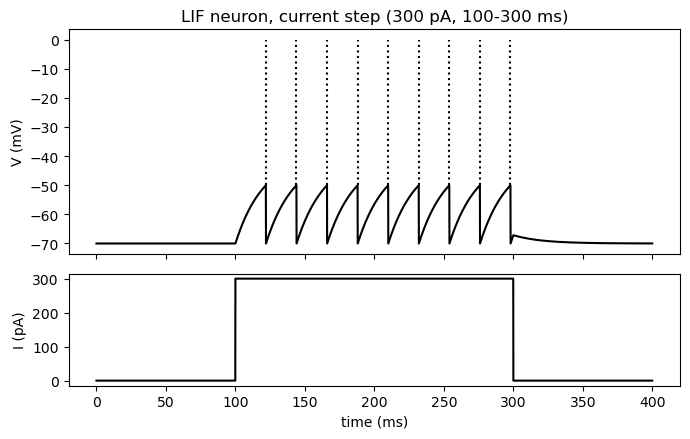

In [3]:
from plots import plot_with_spikes
# --- plot ---
fig, (ax_v, ax_i) = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1]})
# - membrane potential
plot_with_spikes(ax_v, mon, 0)
ax_v.set_ylabel('V (mV)')
ax_v.set_title('LIF neuron, current step (300 pA, 100-300 ms)')

# - current
ax_i.plot(mon.t/ms, mon.I[0]/pA, 'k')
ax_i.set_xlabel('time (ms)')
ax_i.set_ylabel('I (pA)')

plt.tight_layout()